## 玫瑰图是一种特殊的饼图，其每一部分的数值除了对应扇形的角度以外，还体现在扇形的半径长度上。这样可以提供更直观的视觉效果。
## 用来对比不同模型的统计性能差距，可以直接替换柱状图等

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

# 设置样式
try:
    plt.style.use("scatter.mplstyle")
except:
    pass
# 使用Nature常用的无衬线字体，Ubuntu系统兼容
plt.rcParams["font.sans-serif"] = ["Liberation Sans", "Arial", "Helvetica", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

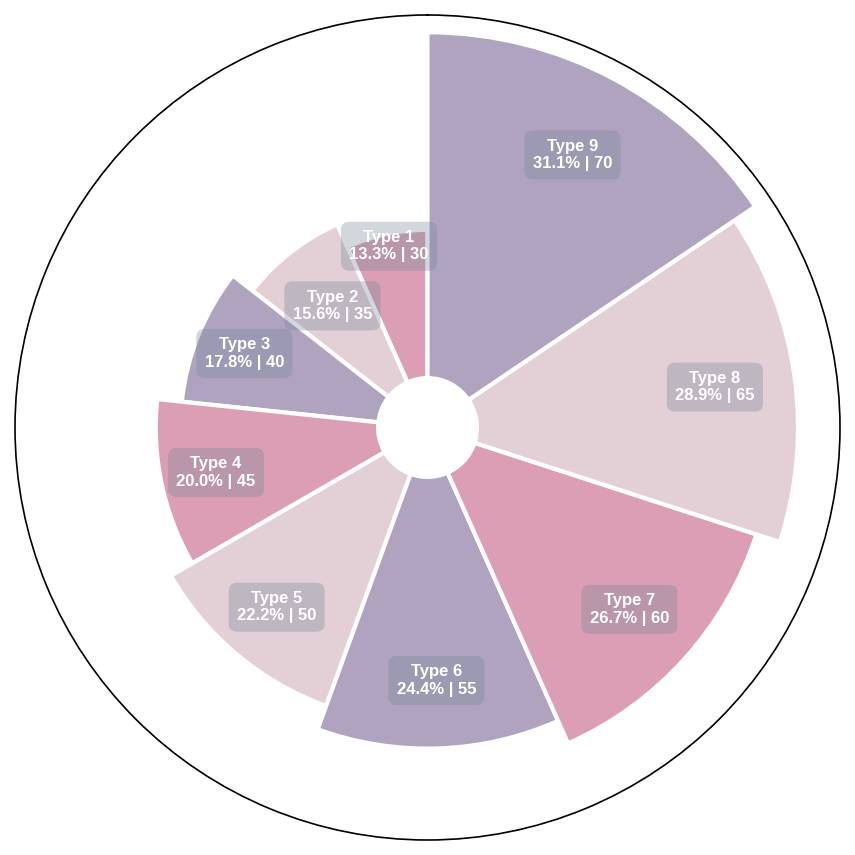

In [ ]:
def create_chart(ax):
    ## Data
    labels = ["Type 1", "Type 2", "Type 3", "Type 4", "Type 5",
              "Type 6", "Type 7", "Type 8", "Type 9"]
    values = [30, 35, 40, 45, 50, 55, 60, 65, 70]

    # Calculate the angle range for each part (0° to 180°)
    values = np.array(values)
    width = 2 * np.pi * values / sum(values)
    color = ["#dc9eb5", "#e3d0d7", "#b0a3c0"]
    color += color
    color += color
    start_x = 0
    for i in range(values.shape[0]):
        start_x += 0.5 * width[i]
        ax.bar(
            start_x, values[i], width=width[i],
            bottom=10.0,
            linewidth=2, edgecolor="#ffffff",
            color=color[i],
        )
        label = f"{labels[i]}\n{width[i]/np.pi*100:.1f}% | {values[i]}"
        r_offset = [5.0, -5.0, 0.0, 0, 0, 0, 0, 0, 0]  # Fine-tune label position
        text_attr = {"ha": "center", "va": "center",
                     "fontweight": "bold"}

        text = ax.text(
            start_x, values[i] * 0.75 + 10 + r_offset[i],
            label, color="#ffffff", fontsize=8, **text_attr,
        )
        text.set_bbox(
            dict(facecolor="#75879655", edgecolor="none",
                 boxstyle="round,pad=0.5")
        )
        # Add the background box to the axes
        start_x += 0.5 * width[i]

    # Set polar coordinate display range, remove axes
    ax.set_yticklabels([])  # Hide polar axis
    ax.set_xticklabels([])  # Hide angle labels
    ax.set_rticks([])  # Hide radius coordinate ticks
    ax.set_xticks([])  # Hide radius coordinate ticks

    ax.set_theta_direction(1)  # Polar plot drawn counterclockwise
    ax.set_theta_offset(np.pi * 0.5)  # Polar plot starts from the top
    plt.subplots_adjust(left=0.3, right=1.0, top=1,
                        bottom=-0.1)

if __name__ == "__main__":
    # load_style()
    fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(8, 5), dpi=150)
    create_chart(ax)
    plt.show()